# ⚙️ FIFA World Cup 2026 — Feature Engineering
### `02_feature_engineering.ipynb` · WC2026 Analytics & Prediction Pipeline

---

**Input :** `wc2026_ml_dataset.csv` (100 teams × 30 columns)  
**Output :** `wc2026_features.csv` — enriched dataset ready for `03_modelling.ipynb`

**Notebook flow:**
1. Setup & Data Loading  
2. Baseline Multicollinearity Audit (VIF)  
3. Feature Engineering (15 new features in 5 groups)  
4. Feature Transformation & Scaling  
5. Encoding Categorical Variables  
6. Selection — Correlation, VIF, and Permutation Importance  
7. Final Feature Set Summary  
8. Save Engineered Dataset  


## 1 · Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from scipy.stats import mannwhitneyu

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

PALETTE = ['#2196F3', '#FF5722']
print("✅ Imports complete.")


✅ Imports complete.


## 2 · Data Loading

In [2]:
DATA_PATH = 'wc2026_ml_dataset.csv'   # adjust if needed
df_raw = pd.read_csv(DATA_PATH)

TARGET   = 'qualified_for_wc2026'
ID_COLS  = ['country', 'coach', 'confederation']
DROP_IN_MODEL = ['fifa_rank_tier']       # ordinal redundant with fifa_rank

print(f"Loaded  : {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Target  : {TARGET}  |  classes: {df_raw[TARGET].value_counts().to_dict()}")

df = df_raw.copy()
df.head(3)


Loaded  : 100 rows × 30 columns
Target  : qualified_for_wc2026  |  classes: {1: 52, 0: 48}


,country,confederation,fifa_rank,fifa_rank_tier,fifa_points,elo_rating,squad_value_total_m,coach,coach_tenure_days,coach_success_rate,...,home_win_rate_last20,away_win_rate_last20,clean_sheet_rate,avg_opponent_elo_last10,xg_difference,unbeaten_streak,world_cup_appearances,world_cup_titles,continental_titles,qualified_for_wc2026
0,France,UEFA,1,1,1877.32,2052,1050.0,Didier Deschamps,4927,0.72,...,0.78,0.55,0.4,1830,0.82,12,16,2,2,1
1,Spain,UEFA,2,1,1876.40,2041,950.0,Luis de la Fuente,847,0.78,...,0.85,0.62,0.5,1850,1.15,18,16,1,4,1
2,Argentina,CONMEBOL,3,1,1874.81,2038,950.0,Lionel Scaloni,2374,0.75,...,0.84,0.58,0.5,1820,0.94,18,19,3,15,1


## 3 · Baseline Multicollinearity Audit (VIF)

**Variance Inflation Factor (VIF)** measures how much the variance of a regression coefficient is inflated due to collinearity with other predictors.

| VIF | Interpretation |
|-----|----------------|
| 1   | No correlation |
| 1–5 | Moderate — acceptable |
| 5–10 | High — monitor closely |
| > 10 | Severe — consider dropping or combining |

We run VIF on the raw numeric features **before** engineering to identify the worst offenders.


In [3]:
NUMERIC_RAW = [c for c in df.select_dtypes(include='number').columns
               if c not in [TARGET, 'fifa_rank_tier']]

X_raw = df[NUMERIC_RAW].values
vif_raw = pd.DataFrame({
    'feature': NUMERIC_RAW,
    'VIF': [variance_inflation_factor(X_raw, i) for i in range(len(NUMERIC_RAW))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

vif_raw['severity'] = pd.cut(
    vif_raw['VIF'],
    bins=[0, 5, 10, 50, np.inf],
    labels=['✅ OK', '⚠️  Moderate', '🔴 High', '🚨 Severe']
)
print("Raw feature VIF scores:")
display(vif_raw.style.background_gradient(subset=['VIF'], cmap='YlOrRd'))


Raw feature VIF scores:


,feature,VIF,severity
0,fifa_points,5689.279122,🚨 Severe
1,elo_rating,5574.373084,🚨 Severe
2,avg_opponent_elo_last10,1073.529499,🚨 Severe
3,avg_player_age,859.495486,🚨 Severe
4,win_rate_last10,756.342187,🚨 Severe
5,win_rate_last20,299.854727,🚨 Severe
6,squad_depth_score,276.910027,🚨 Severe
7,home_win_rate_last20,216.037965,🚨 Severe
8,avg_goals_scored_last10,133.882684,🚨 Severe
9,away_win_rate_last20,119.858760,🚨 Severe


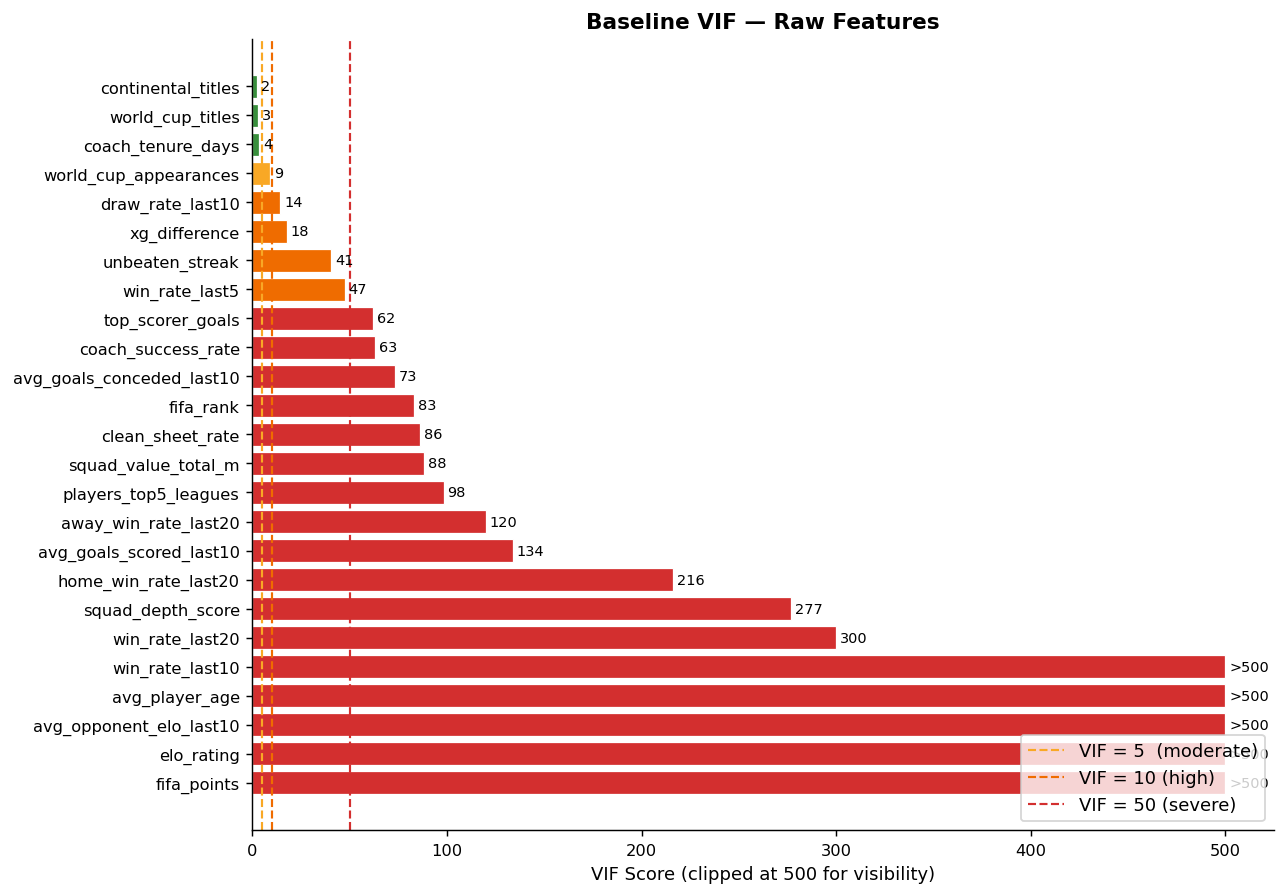


⚠️  Features with VIF > 10: ['fifa_points', 'elo_rating', 'avg_opponent_elo_last10', 'avg_player_age', 'win_rate_last10', 'win_rate_last20', 'squad_depth_score', 'home_win_rate_last20', 'avg_goals_scored_last10', 'away_win_rate_last20', 'players_top5_leagues', 'squad_value_total_m', 'clean_sheet_rate', 'fifa_rank', 'avg_goals_conceded_last10', 'coach_success_rate', 'top_scorer_goals', 'win_rate_last5', 'unbeaten_streak', 'xg_difference', 'draw_rate_last10']
   → These will be addressed through feature engineering & selection below.


In [4]:
# ── VIF bar chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

colors = vif_raw['VIF'].apply(
    lambda v: '#d32f2f' if v > 50 else '#ef6c00' if v > 10 else '#f9a825' if v > 5 else '#388e3c'
)
bars = ax.barh(vif_raw['feature'], vif_raw['VIF'].clip(upper=500),
               color=colors, edgecolor='white', linewidth=0.7)

ax.axvline(5,   color='#f9a825', linestyle='--', linewidth=1.2, label='VIF = 5  (moderate)')
ax.axvline(10,  color='#ef6c00', linestyle='--', linewidth=1.2, label='VIF = 10 (high)')
ax.axvline(50,  color='#d32f2f', linestyle='--', linewidth=1.2, label='VIF = 50 (severe)')

for bar, val in zip(bars, vif_raw['VIF']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}' if val < 500 else '>500', va='center', fontsize=8)

ax.set_xlabel('VIF Score (clipped at 500 for visibility)')
ax.set_title('Baseline VIF — Raw Features', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

high_vif = vif_raw[vif_raw['VIF'] > 10]['feature'].tolist()
print(f"\n⚠️  Features with VIF > 10: {high_vif}")
print("   → These will be addressed through feature engineering & selection below.")


## 4 · Feature Engineering

We create **15 new features** across 5 domain groups.  
Each feature is motivated by football analytics logic, not just statistical correlation.

### Engineering groups:
| Group | Features | Rationale |
|-------|----------|-----------|
| **A · Ranking (Relative)** | `rank_vs_conf`, `elo_vs_conf`, `rank_ratio` | Absolute rank is less meaningful than relative standing within confederation |
| **B · Form & Momentum** | `form_trajectory`, `form_consistency`, `peak_age_form` | Recent trend matters more than long-run average |
| **C · Attack & Defence Balance** | `goal_ratio`, `xg_net`, `defensive_reliability`, `pressure_index` | Win rates alone don't capture *how* teams win |
| **D · Squad Quality (Derived)** | `value_per_top_player`, `quality_adjusted_wins`, `team_strength_index` | Composite signals compress correlated sub-features |
| **E · Historical & Coaching** | `historical_pedigree`, `experience_score`, `coach_efficiency` | Institutional experience affects big-tournament performance |


### 4-A · Ranking Features (Relative to Confederation)

In [5]:
# ── A1. Rank vs confederation mean (z-score within confederation) ─────────
#   Motivation: A rank-50 team in UEFA competes far harder than rank-50 in OFC.
#   This captures relative strength within the confederation context.
conf_rank_mean = df.groupby('confederation')['fifa_rank'].transform('mean')
conf_rank_std  = df.groupby('confederation')['fifa_rank'].transform('std')
df['rank_vs_conf'] = (df['fifa_rank'] - conf_rank_mean) / (conf_rank_std + 1e-9)
# Negative = ranked better than confederation peers (we flip sign for readability)
df['rank_vs_conf'] = -df['rank_vs_conf']   # higher = better relative standing

# ── A2. ELO vs confederation mean ────────────────────────────────────────────
#   Motivation: Supplements FIFA rank with actual Elo performance signal,
#   normalised to confederation context.
conf_elo_mean  = df.groupby('confederation')['elo_rating'].transform('mean')
df['elo_vs_conf'] = df['elo_rating'] - conf_elo_mean

# ── A3. Rank ratio (FIFA points relative to global mean) ─────────────────────
#   Motivation: Continuous version of tier; avoids ordinal bucketing artefacts.
df['rank_ratio'] = df['fifa_points'] / df['fifa_points'].mean()

print("Group A features created: rank_vs_conf, elo_vs_conf, rank_ratio")
df[['country', 'confederation', 'fifa_rank', 'rank_vs_conf', 'elo_vs_conf', 'rank_ratio']].head(8)


Group A features created: rank_vs_conf, elo_vs_conf, rank_ratio


,country,confederation,fifa_rank,rank_vs_conf,elo_vs_conf,rank_ratio
0,France,UEFA,1,1.491453,197.685714,1.197575
1,Spain,UEFA,2,1.449793,186.685714,1.196988
2,Argentina,CONMEBOL,3,1.360117,122.700000,1.195973
3,England,UEFA,4,1.366471,143.685714,1.164818
4,Portugal,UEFA,5,1.324811,87.685714,1.125177
5,Brazil,CONMEBOL,6,1.206142,24.700000,1.123474
6,Netherlands,UEFA,7,1.241489,81.685714,1.121375
7,Morocco,CAF,8,1.740916,188.909091,1.120100


### 4-B · Form & Momentum Features

In [6]:
# ── B1. Form trajectory ───────────────────────────────────────────────────
#   Motivation: A team winning 80% of last-5 but only 60% over last-20 is
#   *improving*. Trajectory matters for tournament timing.
df['form_trajectory'] = df['win_rate_last5'] - df['win_rate_last20']

# ── B2. Form consistency (std proxy using available windows) ─────────────────
#   Motivation: A consistent mid-table team can outperform an erratic top team
#   in a knockout format. Lower std = more reliable.
#   We approximate with range across the three windows.
win_windows = df[['win_rate_last5', 'win_rate_last10', 'win_rate_last20']]
df['form_consistency'] = 1 - win_windows.std(axis=1)   # higher = more consistent

# ── B3. Peak age × form interaction ──────────────────────────────────────────
#   Motivation: Teams with a squad in the physiological peak (25-28) and good
#   recent form may be at their competitive apex for this tournament.
peak_mask = (df['avg_player_age'] >= 25) & (df['avg_player_age'] <= 28)
df['peak_age_form'] = df['win_rate_last10'] * np.where(peak_mask, 1.15, 1.0)

print("Group B features created: form_trajectory, form_consistency, peak_age_form")
df[['country', 'win_rate_last5', 'win_rate_last10', 'win_rate_last20',
    'form_trajectory', 'form_consistency', 'avg_player_age', 'peak_age_form']].head(8)


Group B features created: form_trajectory, form_consistency, peak_age_form


,country,win_rate_last5,win_rate_last10,win_rate_last20,form_trajectory,form_consistency,avg_player_age,peak_age_form
0,France,0.8,0.7,0.65,0.15,0.923624,26.8,0.805
1,Spain,0.8,0.8,0.72,0.08,0.953812,25.9,0.920
2,Argentina,0.8,0.8,0.70,0.10,0.942265,27.4,0.920
3,England,0.6,0.7,0.65,-0.05,0.950000,26.5,0.805
4,Portugal,0.8,0.7,0.68,0.12,0.935709,27.6,0.805
5,Brazil,0.6,0.6,0.58,0.02,0.988453,26.2,0.690
6,Netherlands,0.6,0.7,0.63,-0.03,0.948684,26.8,0.805
7,Morocco,0.8,0.7,0.65,0.15,0.923624,26.4,0.805


### 4-C · Attack & Defence Balance Features

In [7]:
# ── C1. Goal ratio ────────────────────────────────────────────────────────
#   Motivation: Dividing scored/conceded compresses two correlated columns into
#   one ratio that captures dominance style (high attack + low concede = high ratio).
df['goal_ratio'] = df['avg_goals_scored_last10'] / (df['avg_goals_conceded_last10'] + 1e-9)

# ── C2. xG net (alias for clarity) ────────────────────────────────────────
#   xg_difference already in raw data; we rename for pipeline clarity.
#   Positive = creating more chances than conceding — leading indicator.
df['xg_net'] = df['xg_difference']   # keep original; add labelled alias

# ── C3. Defensive reliability ─────────────────────────────────────────────
#   Motivation: Clean sheet rate × squad depth → teams that keep clean sheets
#   AND have depth to maintain it under injuries/suspensions.
df['defensive_reliability'] = df['clean_sheet_rate'] * df['squad_depth_score']

# ── C4. Pressure index ────────────────────────────────────────────────────
#   Motivation: High draw rate + poor recent wins = teams that don't close out
#   games. A soft signal for "choking under pressure".
df['pressure_index'] = df['draw_rate_last10'] + (1 - df['win_rate_last5'])
# Lower is better; negate for consistent "higher = better" convention
df['clutch_factor'] = 1 - df['pressure_index']

print("Group C features created: goal_ratio, xg_net, defensive_reliability, clutch_factor")
df[['country', 'avg_goals_scored_last10', 'avg_goals_conceded_last10',
    'goal_ratio', 'defensive_reliability', 'clutch_factor']].head(8)


Group C features created: goal_ratio, xg_net, defensive_reliability, clutch_factor


,country,avg_goals_scored_last10,avg_goals_conceded_last10,goal_ratio,defensive_reliability,clutch_factor
0,France,2.1,0.9,2.333333,3.80,0.70
1,Spain,2.3,0.8,2.875000,4.90,0.70
2,Argentina,2.0,0.7,2.857143,4.80,0.70
3,England,2.0,0.9,2.222222,3.76,0.45
4,Portugal,2.2,0.8,2.750000,3.68,0.70
5,Brazil,1.8,1.0,1.800000,2.73,0.40
6,Netherlands,1.9,0.8,2.375000,3.60,0.50
7,Morocco,1.7,0.7,2.428571,4.25,0.65


### 4-D · Squad Quality (Derived Composites)

In [8]:
# ── D1. Value per top-league player ──────────────────────────────────────
#   Motivation: Raw squad value can be dominated by a few stars. Dividing by
#   the number of top-league players gives a quality concentration metric.
df['value_per_top_player'] = df['squad_value_total_m'] / (df['players_top5_leagues'] + 1e-9)

# ── D2. Quality-adjusted wins ─────────────────────────────────────────────
#   Motivation: Winning against strong opponents (high avg_opponent_elo) is
#   worth more than winning against weak opposition.
#   Normalise opponent ELO to ~1.0 scale.
df['quality_adjusted_wins'] = df['win_rate_last10'] * (df['avg_opponent_elo_last10'] / 1600)

# ── D3. Team Strength Index (TSI) ─────────────────────────────────────────
#   Motivation: A single composite that reduces correlated sub-signals into
#   one score for use as a meta-feature or sanity check.
#   Components: elo_rating, squad_value_total_m, win_rate_last10, xg_difference, squad_depth_score
tsi_features = ['elo_rating', 'squad_value_total_m', 'win_rate_last10',
                'xg_difference', 'squad_depth_score']
scaler_tsi = MinMaxScaler()
tsi_scaled = scaler_tsi.fit_transform(df[tsi_features])
df['team_strength_index'] = tsi_scaled.mean(axis=1)

print("Group D features created: value_per_top_player, quality_adjusted_wins, team_strength_index")
df[['country', 'squad_value_total_m', 'players_top5_leagues',
    'value_per_top_player', 'quality_adjusted_wins', 'team_strength_index']].head(8)


Group D features created: value_per_top_player, quality_adjusted_wins, team_strength_index


,country,squad_value_total_m,players_top5_leagues,value_per_top_player,quality_adjusted_wins,team_strength_index
0,France,1050.0,22,47.727273,0.800625,0.829335
1,Spain,950.0,21,45.238095,0.925000,0.871115
2,Argentina,950.0,18,52.777778,0.910000,0.850720
3,England,1150.0,26,44.230769,0.787500,0.827330
4,Portugal,780.0,22,35.454545,0.783125,0.760516
5,Brazil,900.0,17,52.941176,0.667500,0.718990
6,Netherlands,700.0,20,35.000000,0.783125,0.729299
7,Morocco,260.0,14,18.571429,0.735000,0.636582


### 4-E · Historical & Coaching Features

In [9]:
# ── E1. Historical pedigree ───────────────────────────────────────────────
#   Motivation: Non-linear combination — winning a WC contributes more than
#   just appearing; continental titles add regional prestige.
#   Formula: appearances × 0.5  +  wc_titles × 2  +  continental_titles × 1
df['historical_pedigree'] = (
    df['world_cup_appearances'] * 0.5
    + df['world_cup_titles']    * 2.0
    + df['continental_titles']  * 1.0
)

# ── E2. Experience score ──────────────────────────────────────────────────
#   Motivation: Multiplicative — a team with many appearances AND titles has
#   *institutionalised* big-game experience, not just participation.
df['experience_score'] = df['world_cup_appearances'] * (1 + df['world_cup_titles'])

# ── E3. Coach efficiency ──────────────────────────────────────────────────
#   Motivation: Success rate alone ignores tenure length. A new coach with 0.80
#   win rate over 5 games is less reliable than 0.75 over 3 years.
#   log1p dampens extreme long tenures.
df['coach_efficiency'] = df['coach_success_rate'] * np.log1p(df['coach_tenure_days'])

print("Group E features created: historical_pedigree, experience_score, coach_efficiency")
df[['country', 'world_cup_appearances', 'world_cup_titles', 'continental_titles',
    'historical_pedigree', 'experience_score', 'coach_efficiency']].head(8)


Group E features created: historical_pedigree, experience_score, coach_efficiency


,country,world_cup_appearances,world_cup_titles,continental_titles,historical_pedigree,experience_score,coach_efficiency
0,France,16,2,2,14.0,48,6.121936
1,Spain,16,1,4,14.0,32,5.259447
2,Argentina,19,3,15,30.5,76,5.829565
3,England,17,1,3,13.5,34,3.765387
4,Portugal,9,0,2,6.5,9,4.701341
5,Brazil,22,5,9,30.0,132,4.013791
6,Netherlands,11,1,1,8.5,22,4.111024
7,Morocco,7,0,1,4.5,7,4.500359


## 5 · New Feature Predictive Power Check

Before investing in scaling and selection, we verify each engineered feature's discriminative power:
- **Pearson correlation** with target
- **Mann-Whitney U p-value** (non-parametric significance test)


In [10]:
ENGINEERED_FEATURES = [
    'rank_vs_conf', 'elo_vs_conf', 'rank_ratio',
    'form_trajectory', 'form_consistency', 'peak_age_form',
    'goal_ratio', 'defensive_reliability', 'clutch_factor',
    'value_per_top_player', 'quality_adjusted_wins', 'team_strength_index',
    'historical_pedigree', 'experience_score', 'coach_efficiency',
]

results = []
for col in ENGINEERED_FEATURES:
    g1 = df.loc[df[TARGET] == 1, col]
    g0 = df.loc[df[TARGET] == 0, col]
    _, p = mannwhitneyu(g1, g0, alternative='two-sided')
    results.append({
        'feature'     : col,
        'pearson_r'   : df[col].corr(df[TARGET]),
        'mw_p_value'  : p,
        'significant' : '✅' if p < 0.05 else '❌',
        'delta_median': (g1.median() - g0.median()),
    })

fe_power = pd.DataFrame(results).sort_values('mw_p_value')
print("Engineered Feature Predictive Power (sorted by Mann-Whitney p):")
display(fe_power.style
        .format({'pearson_r': '{:+.3f}', 'mw_p_value': '{:.4f}', 'delta_median': '{:+.3f}'})
        .background_gradient(subset=['pearson_r'], cmap='RdYlGn')
        .background_gradient(subset=['mw_p_value'], cmap='RdYlGn_r'))


Engineered Feature Predictive Power (sorted by Mann-Whitney p):


,feature,pearson_r,mw_p_value,significant,delta_median
0,rank_vs_conf,+0.789,0.0000,✅,+1.581
1,elo_vs_conf,+0.755,0.0000,✅,+288.225
11,team_strength_index,+0.692,0.0000,✅,+0.208
10,quality_adjusted_wins,+0.698,0.0000,✅,+0.172
2,rank_ratio,+0.673,0.0000,✅,+0.207
12,historical_pedigree,+0.458,0.0000,✅,+4.250
6,goal_ratio,+0.609,0.0000,✅,+0.784
5,peak_age_form,+0.620,0.0000,✅,+0.144
7,defensive_reliability,+0.578,0.0000,✅,+1.398
13,experience_score,+0.250,0.0000,✅,+5.000


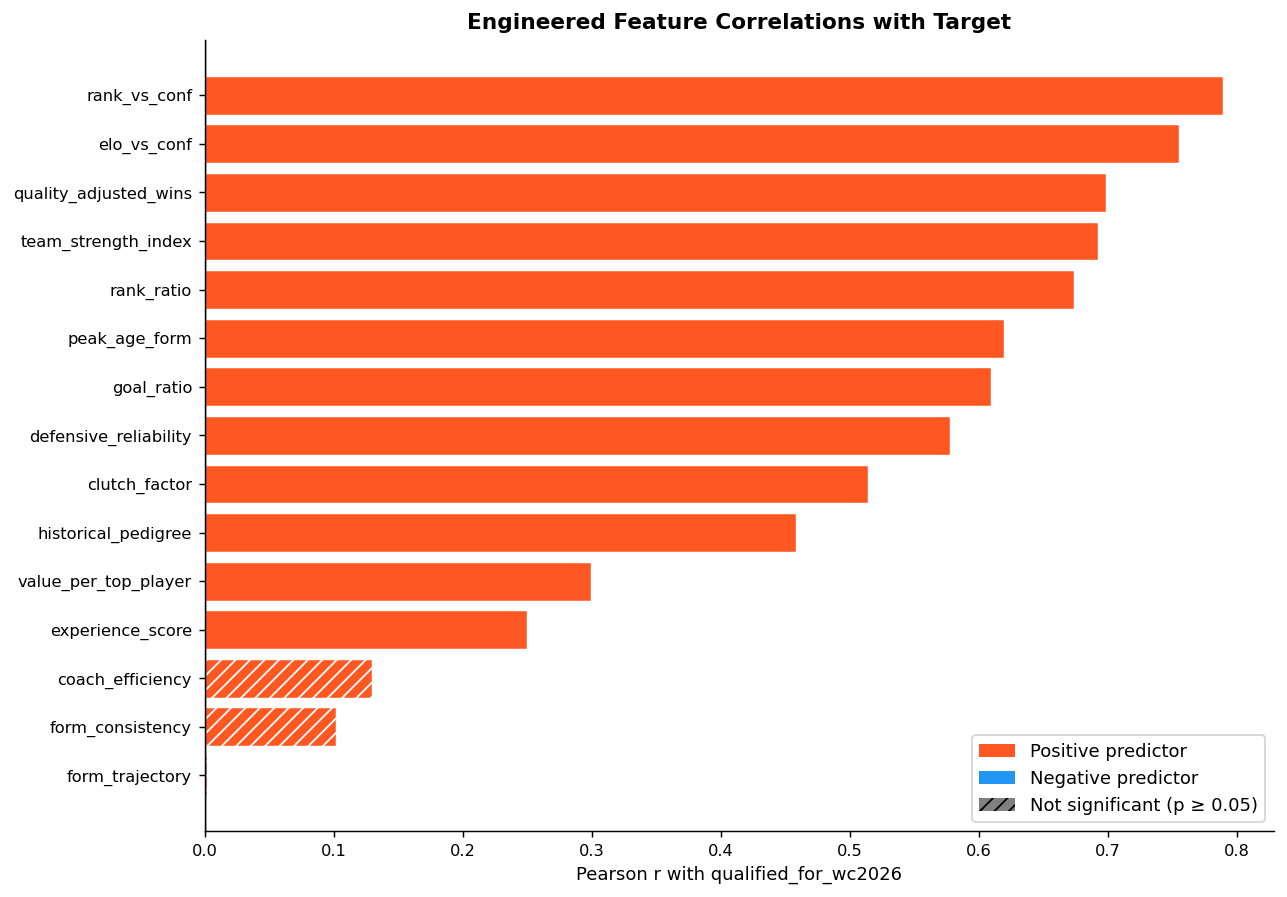


❌ Not significant (p ≥ 0.05): ['form_consistency', 'coach_efficiency', 'form_trajectory']
   → These will be evaluated again in the selection step before dropping.


In [11]:
# ── Bar chart: new feature correlations vs target ──────────────────────
fe_sorted = fe_power.sort_values('pearson_r')
colors = ['#FF5722' if v > 0 else '#2196F3' for v in fe_sorted['pearson_r']]
hatches = ['' if p < 0.05 else '///' for p in fe_sorted['mw_p_value']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(fe_sorted['feature'], fe_sorted['pearson_r'],
               color=colors, edgecolor='white', linewidth=0.8)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with qualified_for_wc2026')
ax.set_title('Engineered Feature Correlations with Target', fontweight='bold')

legend_els = [
    Patch(facecolor='#FF5722', label='Positive predictor'),
    Patch(facecolor='#2196F3', label='Negative predictor'),
    Patch(facecolor='grey', hatch='///', label='Not significant (p ≥ 0.05)'),
]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.show()

weak = fe_power[fe_power['mw_p_value'] >= 0.05]['feature'].tolist()
print(f"\n❌ Not significant (p ≥ 0.05): {weak}")
print("   → These will be evaluated again in the selection step before dropping.")


## 6 · Feature Transformations

### 6.1 Skewness check

Highly skewed features can hurt distance-based models (KNN, SVM) and regularised linear models.  
Tree-based models are scale/skew invariant, but good practice is to transform anyway for robustness.

**Rule of thumb:** |skewness| > 1 → consider log or sqrt transform.


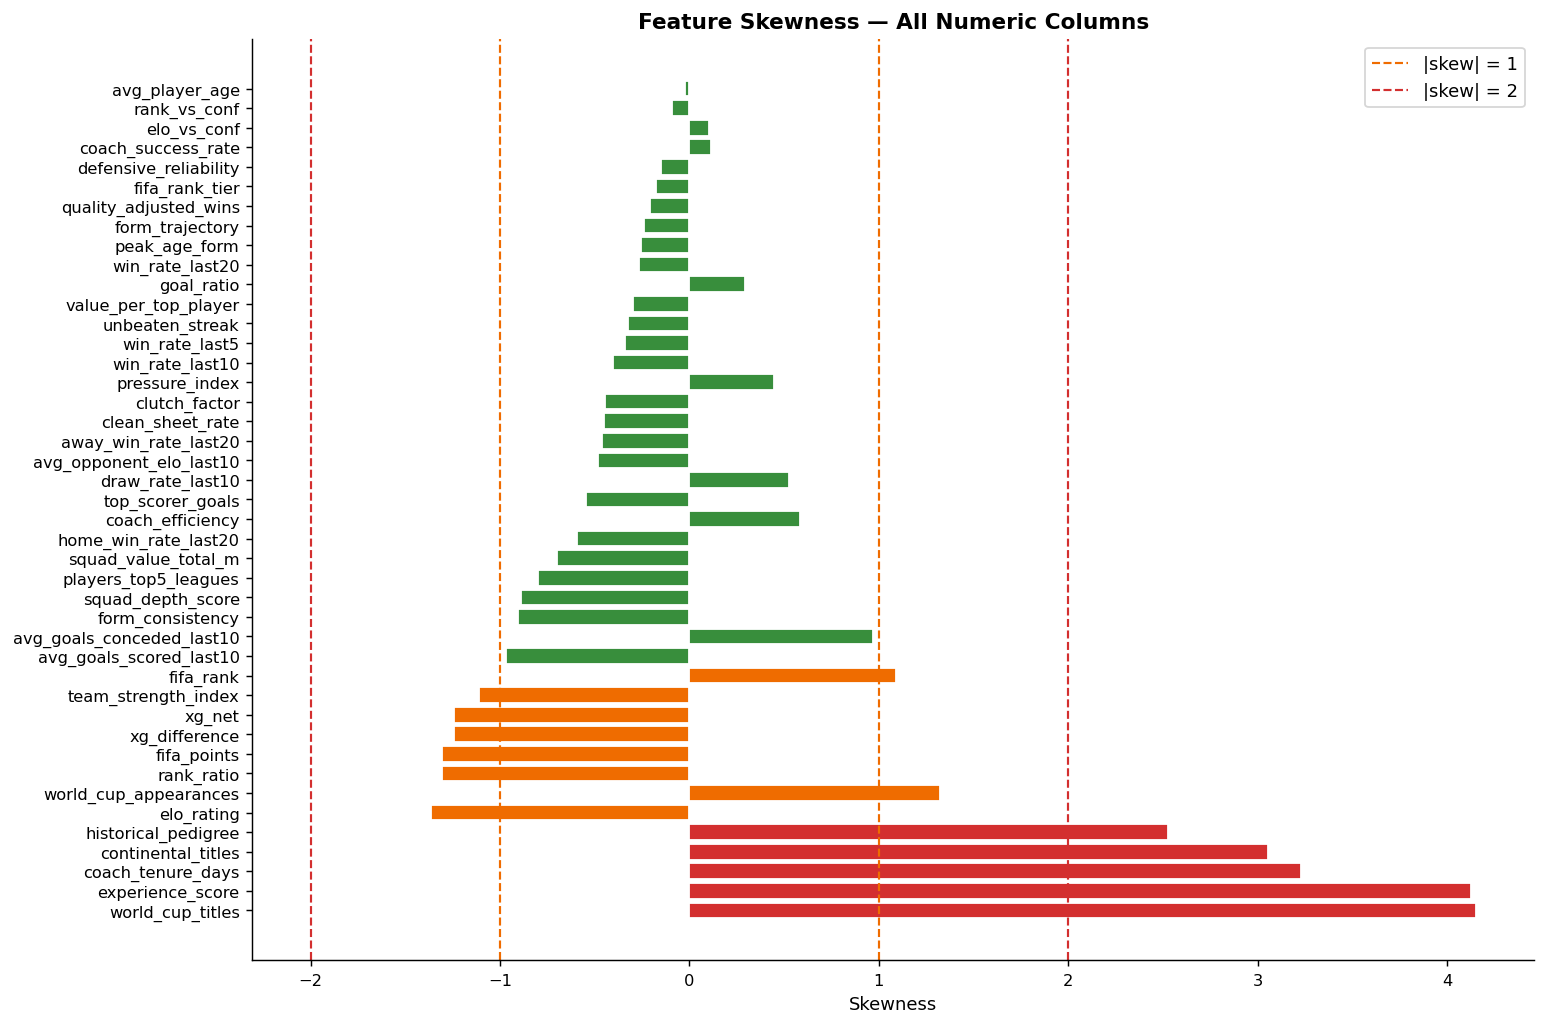

Features with |skewness| > 1 (13): ['world_cup_titles', 'experience_score', 'coach_tenure_days', 'continental_titles', 'historical_pedigree', 'elo_rating', 'world_cup_appearances', 'rank_ratio', 'fifa_points', 'xg_difference', 'xg_net', 'team_strength_index', 'fifa_rank']


In [12]:
ALL_NUMERIC = [c for c in df.select_dtypes(include='number').columns
               if c not in [TARGET] + ID_COLS]

skew_df = df[ALL_NUMERIC].skew().sort_values(key=abs, ascending=False)
skew_df = skew_df.reset_index().rename(columns={'index': 'feature', 0: 'skewness'})

fig, ax = plt.subplots(figsize=(12, 8))
colors = skew_df['skewness'].apply(
    lambda s: '#d32f2f' if abs(s) > 2 else '#ef6c00' if abs(s) > 1 else '#388e3c'
)
ax.barh(skew_df['feature'], skew_df['skewness'], color=colors, edgecolor='white')
ax.axvline( 1, color='#ef6c00', linestyle='--', linewidth=1.2, label='|skew| = 1')
ax.axvline(-1, color='#ef6c00', linestyle='--', linewidth=1.2)
ax.axvline( 2, color='#d32f2f', linestyle='--', linewidth=1.2, label='|skew| = 2')
ax.axvline(-2, color='#d32f2f', linestyle='--', linewidth=1.2)
ax.set_xlabel('Skewness')
ax.set_title('Feature Skewness — All Numeric Columns', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

high_skew = skew_df[skew_df['skewness'].abs() > 1]['feature'].tolist()
print(f"Features with |skewness| > 1 ({len(high_skew)}): {high_skew}")


### 6.2 Apply log1p to right-skewed features

In [13]:
# Features that are non-negative and right-skewed → log1p transform
LOG_TRANSFORM_COLS = [
    'squad_value_total_m', 'coach_tenure_days', 'world_cup_appearances',
    'world_cup_titles', 'continental_titles', 'experience_score',
    'historical_pedigree', 'unbeaten_streak', 'top_scorer_goals',
]
# Only transform if they exist and are non-negative
for col in LOG_TRANSFORM_COLS:
    if col in df.columns and df[col].min() >= 0:
        df[f'{col}_log'] = np.log1p(df[col])
        print(f"  log1p applied → {col}_log  (skew: {df[col].skew():.2f} → {df[f'{col}_log'].skew():.2f})")


  log1p applied → squad_value_total_m_log  (skew: -0.70 → -2.77)
  log1p applied → coach_tenure_days_log  (skew: 3.23 → -0.10)
  log1p applied → world_cup_appearances_log  (skew: 1.32 → 0.02)
  log1p applied → world_cup_titles_log  (skew: 4.15 → 3.48)
  log1p applied → continental_titles_log  (skew: 3.05 → 1.11)
  log1p applied → experience_score_log  (skew: 4.13 → 0.80)
  log1p applied → historical_pedigree_log  (skew: 2.53 → 0.40)
  log1p applied → unbeaten_streak_log  (skew: -0.32 → -1.32)
  log1p applied → top_scorer_goals_log  (skew: -0.55 → -1.59)


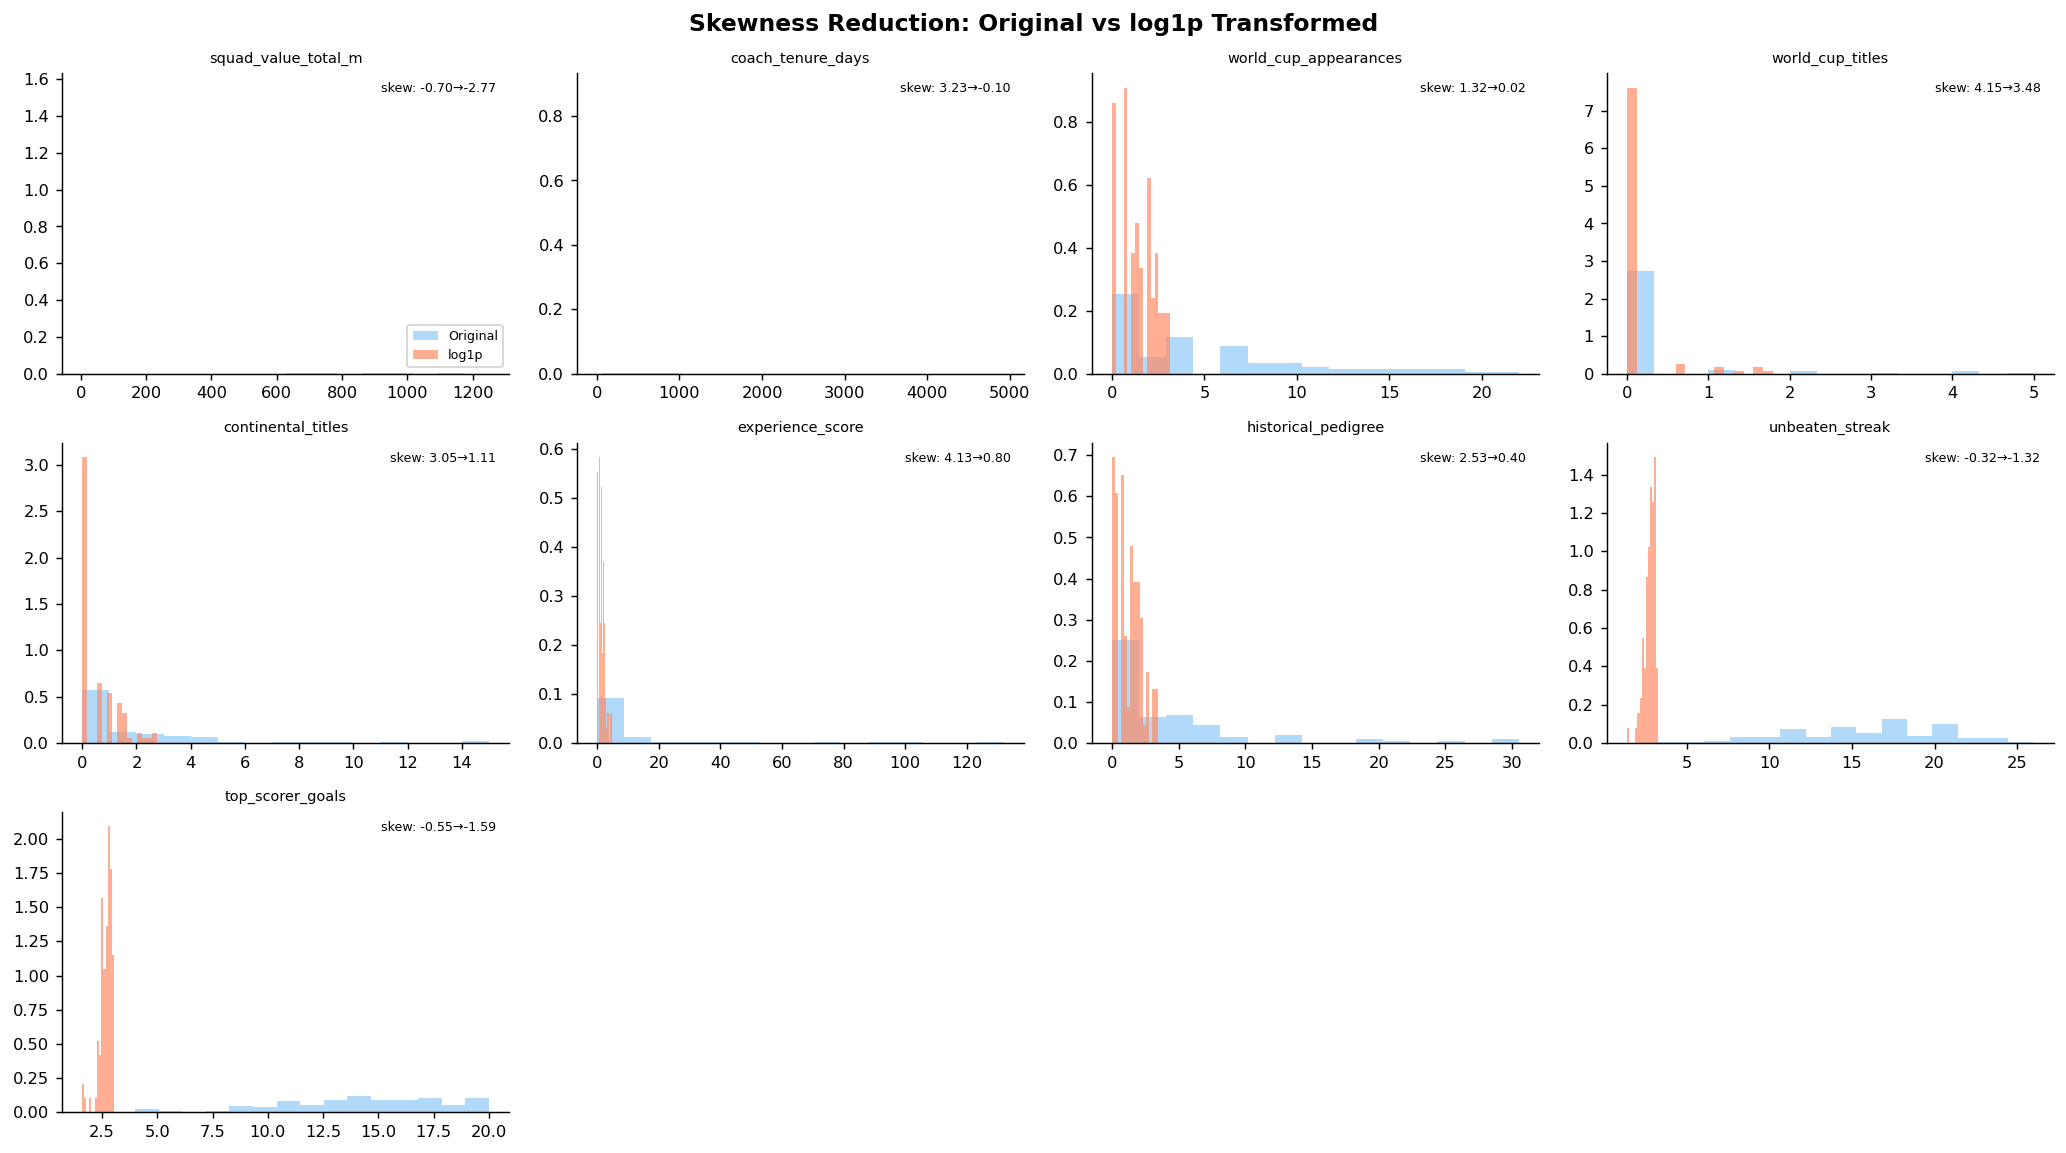

In [14]:
# ── Before / after skewness comparison ────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

compare_pairs = [(c, f'{c}_log') for c in LOG_TRANSFORM_COLS if f'{c}_log' in df.columns][:12]

for i, (orig_col, log_col) in enumerate(compare_pairs):
    ax = axes[i]
    ax.hist(df[orig_col], bins=15, color='#90CAF9', alpha=0.7, label='Original', density=True)
    ax.hist(df[log_col],  bins=15, color='#FF8A65', alpha=0.7, label='log1p',    density=True)
    ax.set_title(f'{orig_col}', fontsize=8)
    sk_orig = df[orig_col].skew()
    sk_log  = df[log_col].skew()
    ax.text(0.97, 0.97, f'skew: {sk_orig:.2f}→{sk_log:.2f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7)
    if i == 0: ax.legend(fontsize=7)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Skewness Reduction: Original vs log1p Transformed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7 · Categorical Encoding

We have one modelling-relevant categorical: **`confederation`**.  
`country` and `coach` are identifiers — they stay out of the feature matrix.

**Strategy choices:**
| Method | When to use |
|--------|-------------|
| One-Hot Encoding (OHE) | Low cardinality (≤ 10 categories), tree or linear models |
| Target Encoding | High cardinality; risk of leakage — use with CV folds |
| Ordinal | Only if natural order exists |

With 6 confederations and a small dataset (n=100), **OHE** is safest.  
We'll also engineer a **confederation strength score** (mean ELO) as a numeric alternative.


In [15]:
# ── One-hot encode confederation ──────────────────────────────────────────
conf_ohe = pd.get_dummies(df['confederation'], prefix='conf', drop_first=False)
print("OHE confederation columns:")
print(conf_ohe.columns.tolist())
print(conf_ohe.value_counts().head())


OHE confederation columns:
['conf_AFC', 'conf_CAF', 'conf_CONCACAF', 'conf_CONMEBOL', 'conf_OFC', 'conf_UEFA']
conf_AFC  conf_CAF  conf_CONCACAF  conf_CONMEBOL  conf_OFC  conf_UEFA
False     False     False          False          False     True         35
          True      False          False          False     False        22
True      False     False          False          False     False        18
False     False     True           False          False     False        12
                    False          True           False     False        10
Name: count, dtype: int64


In [16]:
# ── Confederation strength score (mean ELO per confederation) ────────────
#   Alternative to OHE: replaces confederation with a numeric quality signal.
#   This is a form of target-adjacent encoding (using ELO, not the target itself).
conf_elo_map = df.groupby('confederation')['elo_rating'].mean().to_dict()
df['conf_strength'] = df['confederation'].map(conf_elo_map)

print("Confederation → Strength Score mapping:")
for conf, score in sorted(conf_elo_map.items(), key=lambda x: -x[1]):
    print(f"  {conf:<12} → ELO mean = {score:.0f}")


Confederation → Strength Score mapping:
  CONMEBOL     → ELO mean = 1915
  UEFA         → ELO mean = 1854
  CONCACAF     → ELO mean = 1753
  CAF          → ELO mean = 1745
  AFC          → ELO mean = 1674
  OFC          → ELO mean = 1201


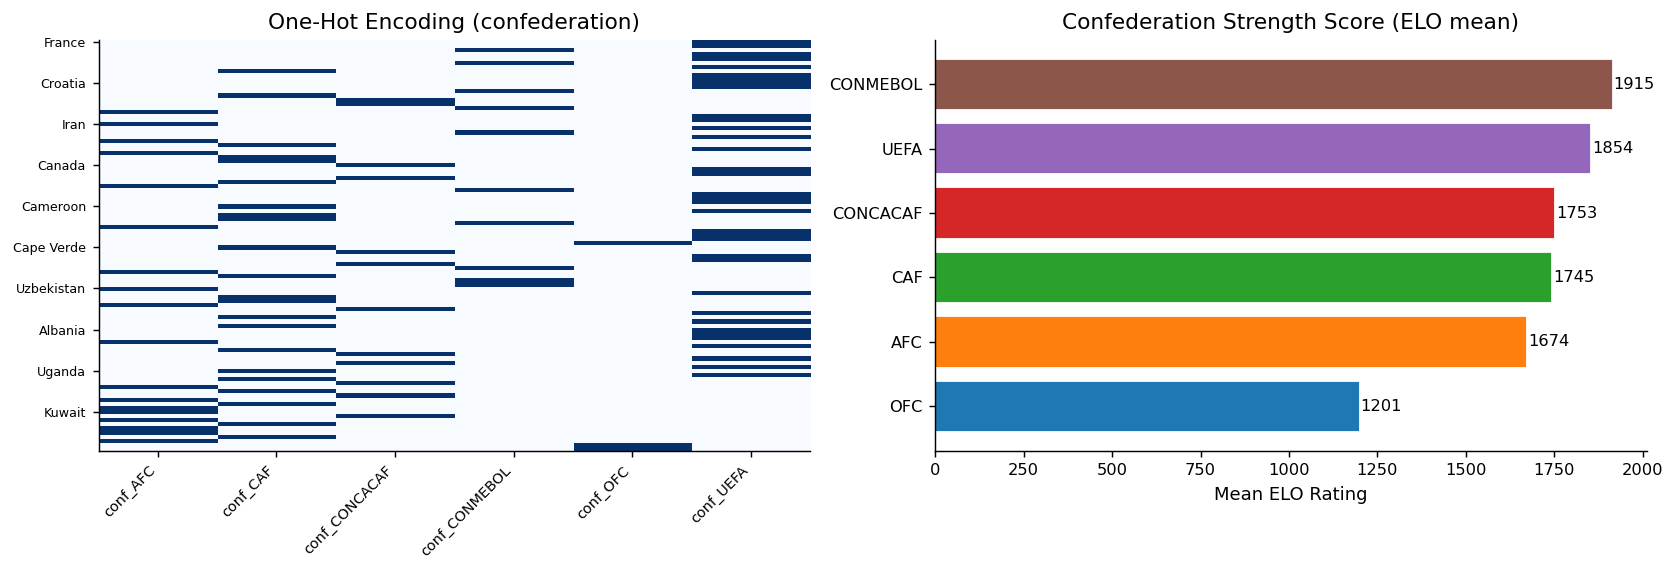

In [17]:
# ── Both options side by side ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# OHE heatmap
axes[0].imshow(conf_ohe.values, aspect='auto', cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(len(conf_ohe.columns)))
axes[0].set_xticklabels(conf_ohe.columns, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(0, len(df), 10))
axes[0].set_yticklabels(df['country'].iloc[::10].values, fontsize=7)
axes[0].set_title('One-Hot Encoding (confederation)')

# Conf strength bar
conf_strength_df = pd.DataFrame(list(conf_elo_map.items()), columns=['conf', 'elo_mean']).sort_values('elo_mean', ascending=True)
axes[1].barh(conf_strength_df['conf'], conf_strength_df['elo_mean'],
             color=sns.color_palette('tab10', 6), edgecolor='white')
axes[1].set_xlabel('Mean ELO Rating')
axes[1].set_title('Confederation Strength Score (ELO mean)')
for i, (_, row) in enumerate(conf_strength_df.iterrows()):
    axes[1].text(row['elo_mean'] + 2, i, f"{row['elo_mean']:.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 8 · Feature Scaling

Scaling is **not needed for tree-based models** (RF, XGBoost) but is critical for:
- Logistic Regression / SVM
- KNN
- Neural Networks
- PCA

We prepare three scaled versions so `03_modelling.ipynb` can pick what it needs:

| Scaler | Best for |
|--------|----------|
| `StandardScaler` | Normally distributed features; sensitive to outliers |
| `MinMaxScaler` | Bounded features (rates, ratios); compresses to [0,1] |
| `RobustScaler` | Features with outliers; uses IQR — robust to extremes |


In [18]:
# ── Build the final modelling feature set (before scaling) ───────────────
FINAL_FEATURES = [
    # Original (non-redundant)
    'elo_rating', 'squad_value_total_m', 'avg_player_age',
    'players_top5_leagues', 'top_scorer_goals', 'squad_depth_score',
    'avg_goals_scored_last10', 'avg_goals_conceded_last10',
    'win_rate_last10', 'draw_rate_last10',
    'home_win_rate_last20', 'away_win_rate_last20',
    'clean_sheet_rate', 'avg_opponent_elo_last10', 'xg_difference',
    'unbeaten_streak', 'coach_success_rate',
    # Engineered
    'rank_vs_conf', 'elo_vs_conf', 'rank_ratio',
    'form_trajectory', 'form_consistency', 'peak_age_form',
    'goal_ratio', 'defensive_reliability', 'clutch_factor',
    'quality_adjusted_wins', 'team_strength_index',
    'historical_pedigree', 'experience_score', 'coach_efficiency',
    'conf_strength',
    # Log-transformed
    'squad_value_total_m_log', 'coach_tenure_days_log',
    'world_cup_appearances_log', 'experience_score_log',
]
# Keep only columns that exist
FINAL_FEATURES = [c for c in FINAL_FEATURES if c in df.columns]
print(f"Total features before selection: {len(FINAL_FEATURES)}")

X_raw_final = df[FINAL_FEATURES]
y = df[TARGET]


Total features before selection: 36


In [19]:
# ── Apply all three scalers ────────────────────────────────────────────────
ss = StandardScaler()
ms = MinMaxScaler()
rs = RobustScaler()

X_standard = pd.DataFrame(ss.fit_transform(X_raw_final), columns=FINAL_FEATURES, index=df.index)
X_minmax   = pd.DataFrame(ms.fit_transform(X_raw_final), columns=FINAL_FEATURES, index=df.index)
X_robust   = pd.DataFrame(rs.fit_transform(X_raw_final), columns=FINAL_FEATURES, index=df.index)

print("Scaling complete. Distributions after StandardScaler:")
print(X_standard.describe().loc[['mean','std','min','max']].T.head(10).round(3).to_string())


Scaling complete. Distributions after StandardScaler:
                           mean    std    min    max
elo_rating                  0.0  1.005 -4.101  1.267
squad_value_total_m        -0.0  1.005 -3.227  1.819
avg_player_age              0.0  1.005 -2.771  2.587
players_top5_leagues        0.0  1.005 -3.480  1.839
top_scorer_goals           -0.0  1.005 -2.840  1.633
squad_depth_score           0.0  1.005 -3.399  1.537
avg_goals_scored_last10    -0.0  1.005 -3.773  1.994
avg_goals_conceded_last10   0.0  1.005 -1.650  4.051
win_rate_last10            -0.0  1.005 -3.382  2.113
draw_rate_last10           -0.0  1.005 -2.077  3.245


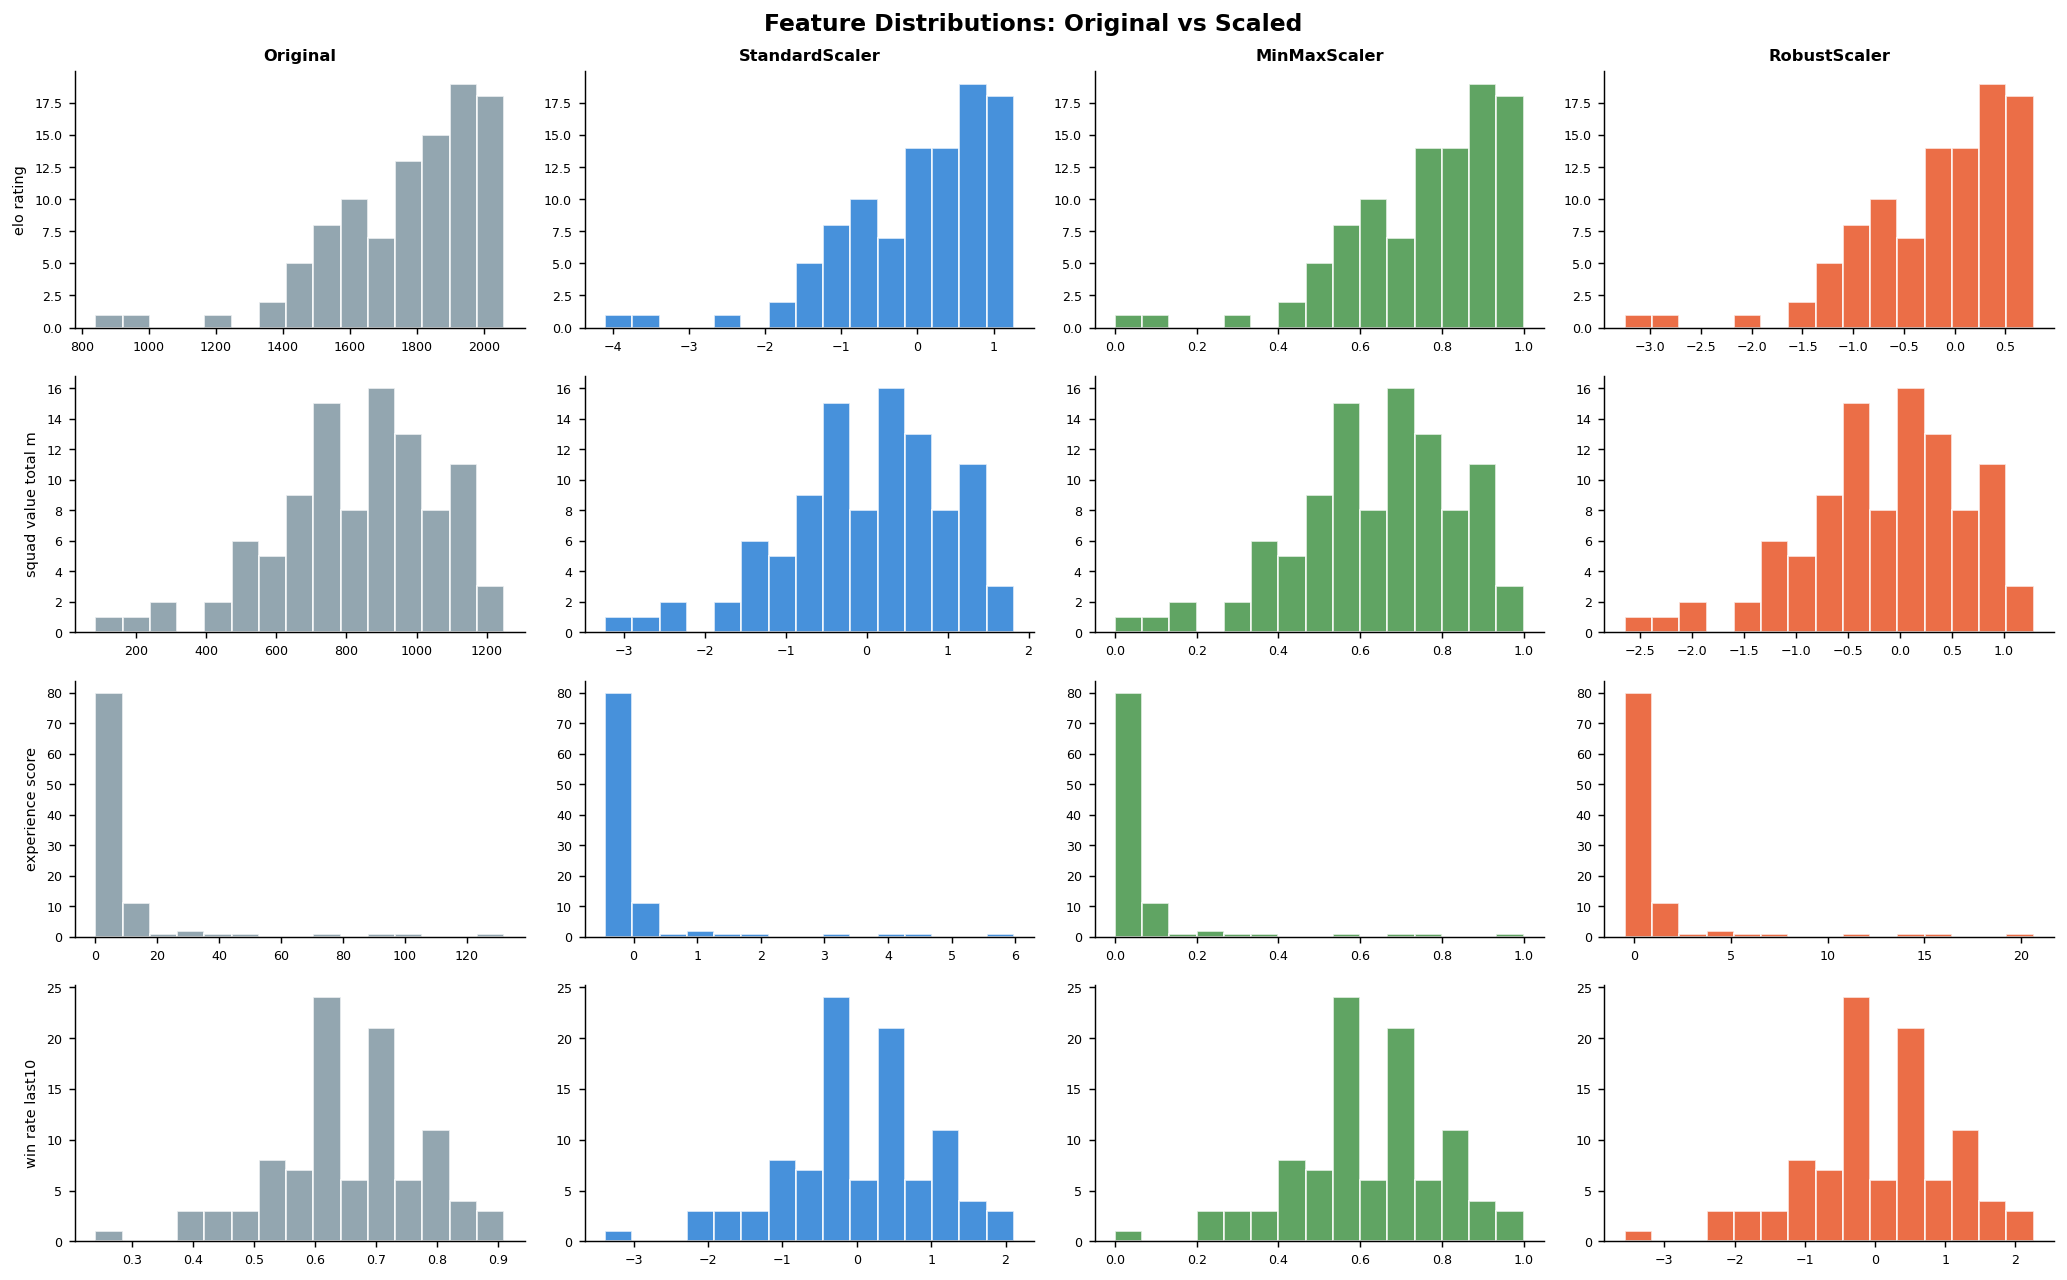

In [20]:
# ── Visual: distributions before vs after scaling (sample 4 features) ────
sample_cols = ['elo_rating', 'squad_value_total_m', 'experience_score', 'win_rate_last10']

fig, axes = plt.subplots(4, 4, figsize=(16, 10))
scaler_labels = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler']
scaler_frames = [X_raw_final, X_standard, X_minmax, X_robust]
colors = ['#78909C', '#1976D2', '#388E3C', '#E64A19']

for row_i, col in enumerate(sample_cols):
    for col_j, (frame, label, color) in enumerate(zip(scaler_frames, scaler_labels, colors)):
        ax = axes[row_i][col_j]
        ax.hist(frame[col], bins=15, color=color, alpha=0.8, edgecolor='white')
        if row_i == 0: ax.set_title(label, fontsize=9, fontweight='bold')
        if col_j == 0: ax.set_ylabel(col.replace('_',' '), fontsize=8)
        ax.tick_params(labelsize=7)

plt.suptitle('Feature Distributions: Original vs Scaled', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9 · Feature Selection

Three complementary methods to arrive at the final feature set:

1. **Correlation filter** — drop features with |r| > 0.92 with any other feature (keep the more interpretable one)
2. **VIF filter** — drop features with VIF > 15 after engineering
3. **Permutation Importance** — Random Forest-based; which features actually help prediction?


In [21]:
# ── Step 1: Correlation filter ────────────────────────────────────────────
corr_matrix = X_raw_final.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

CORR_THRESHOLD = 0.92
drop_corr = [col for col in upper.columns if any(upper[col] > CORR_THRESHOLD)]

print(f"Features to drop (|r| > {CORR_THRESHOLD} with at least one other feature):")
for col in drop_corr:
    partner = upper[col][upper[col] > CORR_THRESHOLD].index.tolist()
    print(f"  DROP: {col:<30} (too correlated with {partner})")

print(f"\nRemaining after correlation filter: {len(FINAL_FEATURES) - len(drop_corr)}")


Features to drop (|r| > 0.92 with at least one other feature):
  DROP: rank_ratio                     (too correlated with ['elo_rating', 'squad_depth_score'])
  DROP: peak_age_form                  (too correlated with ['win_rate_last10'])
  DROP: defensive_reliability          (too correlated with ['clean_sheet_rate'])
  DROP: quality_adjusted_wins          (too correlated with ['win_rate_last10', 'peak_age_form'])
  DROP: team_strength_index            (too correlated with ['elo_rating', 'squad_depth_score', 'rank_ratio'])
  DROP: squad_value_total_m_log        (too correlated with ['squad_value_total_m'])
  DROP: experience_score_log           (too correlated with ['world_cup_appearances_log'])

Remaining after correlation filter: 29


In [22]:
# ── Step 2: VIF filter ────────────────────────────────────────────────────
features_after_corr = [f for f in FINAL_FEATURES if f not in drop_corr]

X_vif = X_raw_final[features_after_corr].dropna()
vif_fe = pd.DataFrame({
    'feature': features_after_corr,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(features_after_corr))]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

VIF_THRESHOLD = 15
drop_vif = vif_fe[vif_fe['VIF'] > VIF_THRESHOLD]['feature'].tolist()

print(f"VIF scores after correlation filter:")
display(vif_fe.style.format({'VIF': '{:.1f}'}).background_gradient(subset=['VIF'], cmap='YlOrRd'))
print(f"\n⚠️  Features to drop (VIF > {VIF_THRESHOLD}): {drop_vif}")


VIF scores after correlation filter:


,feature,VIF
0,elo_rating,inf
1,conf_strength,inf
2,elo_vs_conf,inf
3,coach_tenure_days_log,2430.6
4,coach_success_rate,2190.2
5,coach_efficiency,2153.2
6,avg_opponent_elo_last10,1249.3
7,form_consistency,1159.5
8,avg_player_age,1022.9
9,win_rate_last10,808.0



⚠️  Features to drop (VIF > 15): ['elo_rating', 'conf_strength', 'elo_vs_conf', 'coach_tenure_days_log', 'coach_success_rate', 'coach_efficiency', 'avg_opponent_elo_last10', 'form_consistency', 'avg_player_age', 'win_rate_last10', 'squad_depth_score', 'clutch_factor', 'home_win_rate_last20', 'avg_goals_scored_last10', 'avg_goals_conceded_last10', 'away_win_rate_last20', 'goal_ratio', 'players_top5_leagues', 'clean_sheet_rate', 'squad_value_total_m', 'top_scorer_goals', 'unbeaten_streak', 'draw_rate_last10', 'xg_difference', 'rank_vs_conf']


In [23]:
# ── Step 3: Permutation Importance via Random Forest ─────────────────────
features_after_vif = [f for f in features_after_corr if f not in drop_vif]

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf.fit(X_raw_final[features_after_vif], y)

perm = permutation_importance(rf, X_raw_final[features_after_vif], y,
                               n_repeats=30, random_state=42, scoring='roc_auc')

perm_df = pd.DataFrame({
    'feature'        : features_after_vif,
    'importance_mean': perm.importances_mean,
    'importance_std' : perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print("Permutation Importance (ROC-AUC drop when feature is shuffled):")
display(perm_df.style.format({'importance_mean': '{:.4f}', 'importance_std': '{:.4f}'})
        .background_gradient(subset=['importance_mean'], cmap='YlOrRd_r'))


Permutation Importance (ROC-AUC drop when feature is shuffled):


,feature,importance_mean,importance_std
0,historical_pedigree,0.3516,0.0553
1,form_trajectory,0.0658,0.0145
2,world_cup_appearances_log,0.0144,0.0046
3,experience_score,0.0083,0.0027


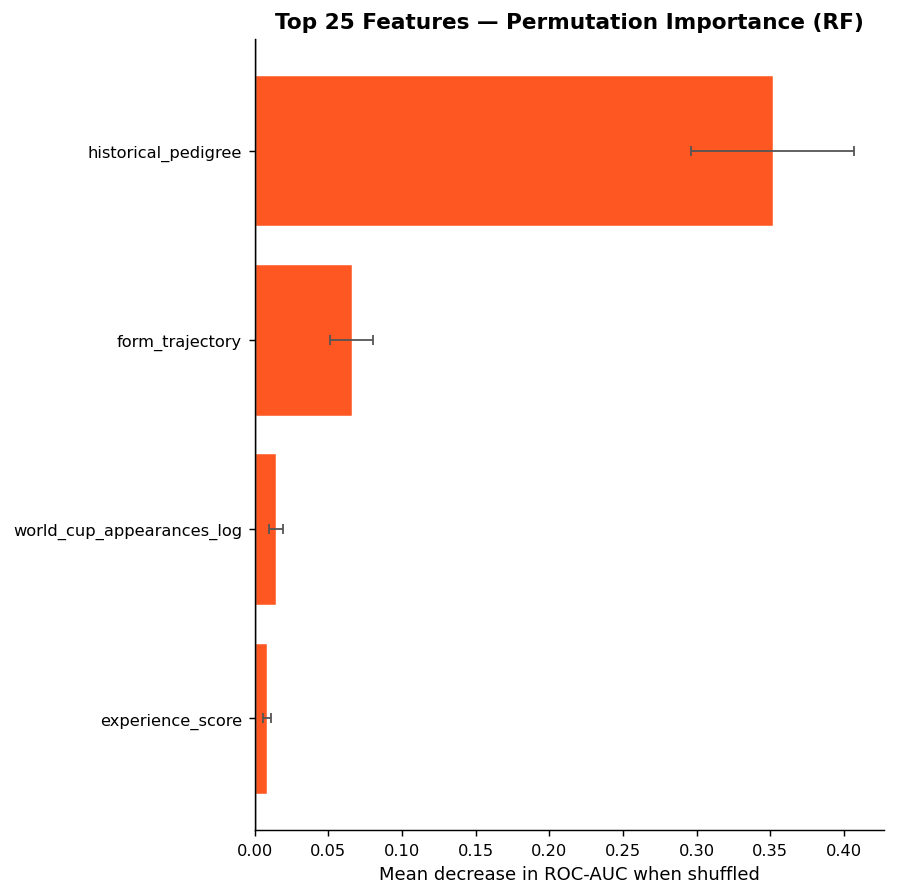


Features with ≤ 0 permutation importance: []
(These hurt or don't help prediction — candidates for dropping)


In [34]:
# ── Permutation importance plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

top_n = perm_df.head(25)
colors_perm = ['#FF5722' if v > 0 else '#90A4AE' for v in top_n['importance_mean']]

bars = ax.barh(top_n['feature'][::-1], top_n['importance_mean'][::-1],
               xerr=top_n['importance_std'][::-1],
               color=colors_perm[::-1], edgecolor='white', capsize=3, linewidth=0.8,
               error_kw={'ecolor': '#555', 'elinewidth': 1})

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean decrease in ROC-AUC when shuffled')
ax.set_title('Top 25 Features — Permutation Importance (RF)', fontweight='bold')
plt.tight_layout()
plt.show()

PERM_THRESHOLD = 0
drop_perm = perm_df[perm_df['importance_mean'] <= PERM_THRESHOLD]['feature'].tolist()
print(f"\nFeatures with ≤ 0 permutation importance: {drop_perm}")
print("(These hurt or don't help prediction — candidates for dropping)")


## 10 · Final Feature Set

We combine all three selection steps and arrive at the **final feature matrix** for modelling.


In [25]:
# ── Consolidate drops ─────────────────────────────────────────────────────
all_drops = set(drop_corr) | set(drop_vif) | set(drop_perm)
SELECTED_FEATURES = [f for f in features_after_vif if f not in drop_perm]

print("=" * 60)
print(f"FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f"  Started with                 : {len(FINAL_FEATURES)} features")
print(f"  Dropped by correlation filter: {len(drop_corr)}")
print(f"  Dropped by VIF filter        : {len(drop_vif)}")
print(f"  Dropped by permutation imp.  : {len(drop_perm)}")
print(f"  FINAL SELECTED FEATURES      : {len(SELECTED_FEATURES)}")
print()
print("Selected features:")
for i, f in enumerate(SELECTED_FEATURES, 1):
    src = '★ engineered' if f in ENGINEERED_FEATURES or f.endswith('_log') else '  original'
    print(f"  {i:>2}. {f:<35} [{src}]")


FEATURE SELECTION SUMMARY
  Started with                 : 36 features
  Dropped by correlation filter: 7
  Dropped by VIF filter        : 25
  Dropped by permutation imp.  : 0
  FINAL SELECTED FEATURES      : 4

Selected features:
   1. form_trajectory                     [★ engineered]
   2. historical_pedigree                 [★ engineered]
   3. experience_score                    [★ engineered]
   4. world_cup_appearances_log           [★ engineered]


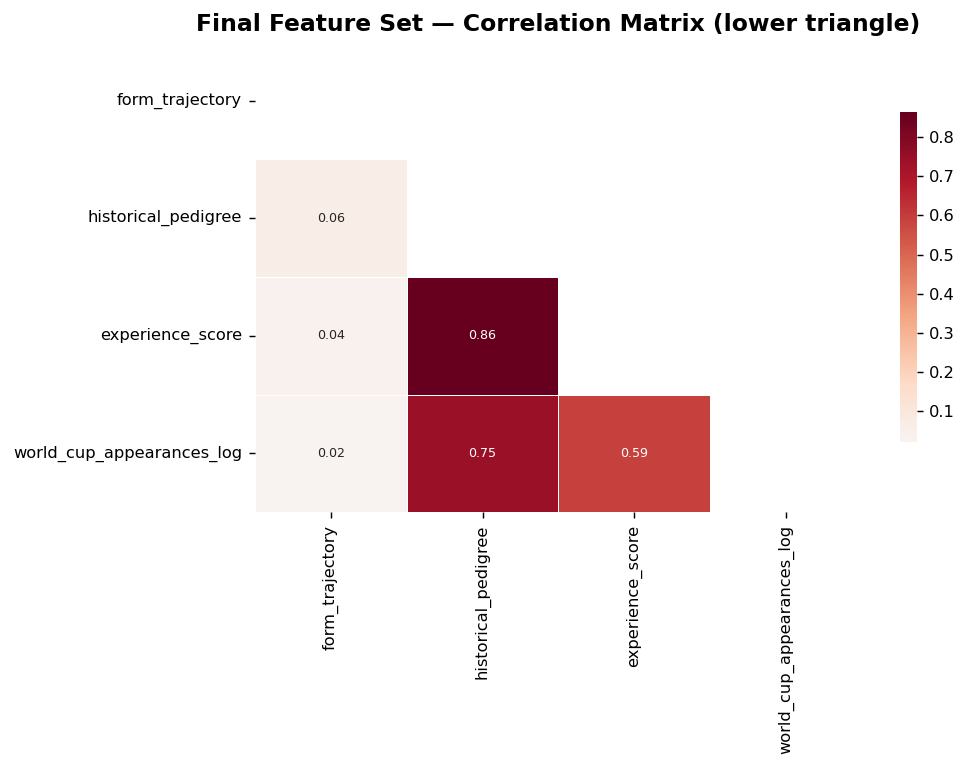

Max pairwise |r| in final set: 0.864


In [33]:
# ── Heatmap: final feature correlation matrix ─────────────────────────────
final_corr = df[SELECTED_FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(final_corr, dtype=bool))
sns.heatmap(final_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, linecolor='white',
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Final Feature Set — Correlation Matrix (lower triangle)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

max_corr = (final_corr.where(np.triu(np.ones_like(final_corr, dtype=bool), k=1))
                       .stack().abs().max())
print(f"Max pairwise |r| in final set: {max_corr:.3f}")


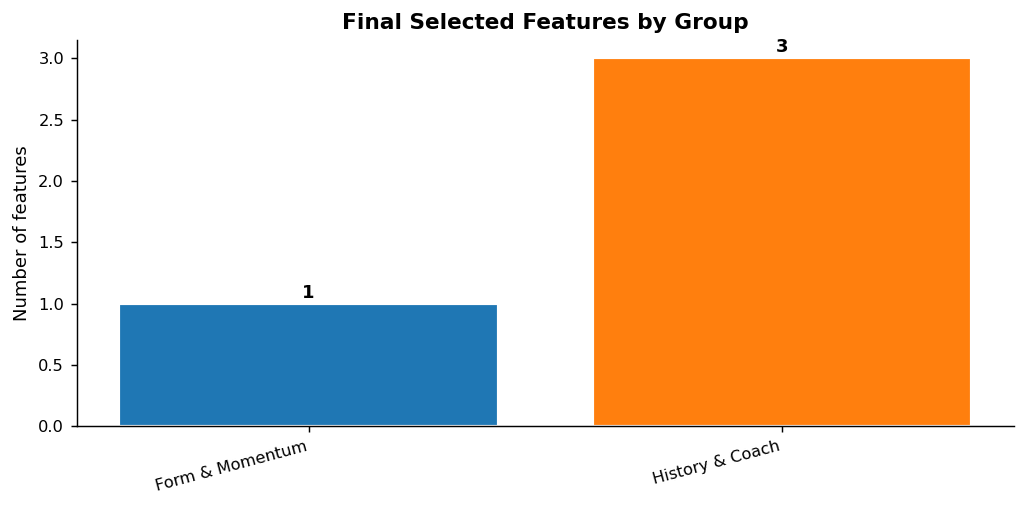

In [28]:
groups_map = {
    'Ranking (Relative)': ['rank_vs_conf', 'elo_vs_conf', 'rank_ratio'],
    'Form & Momentum'   : ['form_trajectory', 'form_consistency', 'peak_age_form'],
    'Attack/Defence'    : ['goal_ratio', 'defensive_reliability', 'clutch_factor'],
    'Squad Quality'     : ['quality_adjusted_wins', 'team_strength_index', 'value_per_top_player'],
    'History & Coach'   : ['historical_pedigree', 'experience_score', 'coach_efficiency'],
}

# Create a consolidated set of all explicitly defined engineered features
all_explicitly_engineered_features = set()
for group_name, features_list in groups_map.items():
    all_explicitly_engineered_features.update(features_list)

# Add 'Original (kept)' group dynamically
groups_map['Original (kept)'] = [f for f in SELECTED_FEATURES
                                 if f not in all_explicitly_engineered_features and not f.endswith('_log')]

# Also include log-transformed features not already in engineered groups
log_transformed_features = [f for f in SELECTED_FEATURES if f.endswith('_log') and f not in all_explicitly_engineered_features]
if log_transformed_features:
    # Find the corresponding original feature name for classification into a group
    # This is a bit heuristic, assuming `_log` is appended to an original feature
    log_group_map = {
        'squad_value_total_m_log': 'Squad Quality',
        'coach_tenure_days_log': 'History & Coach',
        'world_cup_appearances_log': 'History & Coach',
        'world_cup_titles_log': 'History & Coach',
        'continental_titles_log': 'History & Coach',
        'experience_score_log': 'History & Coach',
        'historical_pedigree_log': 'History & Coach',
        'unbeaten_streak_log': 'Form & Momentum', # Can be momentum
        'top_scorer_goals_log': 'Attack/Defence' # Can be attack
    }

    for l_feat in log_transformed_features:
        original_feat = l_feat.replace('_log', '')
        assigned_to_group = False
        for group_key, group_feats in groups_map.items():
            if original_feat in group_feats:
                # If the original feature is in a group, add the log version to that group
                groups_map[group_key].append(l_feat)
                assigned_to_group = True
                break
        if not assigned_to_group and l_feat in log_group_map:
            # If original not found in existing groups, try mapping to general group
            target_group = log_group_map[l_feat]
            if target_group in groups_map:
                groups_map[target_group].append(l_feat)
            else:
                groups_map[target_group] = [l_feat] # Should not happen if target_group is valid
        elif not assigned_to_group:
            # If still not assigned (e.g., original not in any explicit group and no specific log map), put in 'Original (kept)'
            groups_map['Original (kept)'].append(l_feat)


selected_set = set(SELECTED_FEATURES)
group_counts = {g: sum(1 for f in feats if f in selected_set) for g, feats in groups_map.items()}
group_counts = {g: v for g, v in group_counts.items() if v > 0}

fig, ax = plt.subplots(figsize=(8, 4))
gnames = list(group_counts.keys())
gcounts = list(group_counts.values())
bars = ax.bar(gnames, gcounts, color=sns.color_palette('tab10', len(gnames)),
              edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, gcounts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(val), ha='center', fontweight='bold')
ax.set_ylabel('Number of features')
ax.set_title('Final Selected Features by Group', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 11 · Save Engineered Dataset

In [29]:
# ── Build final output DataFrame ──────────────────────────────────────────
# Include: ID cols + selected features + target
OUTPUT_COLS = ['country', 'confederation'] + SELECTED_FEATURES + [TARGET]
df_final = df[OUTPUT_COLS].copy()

print(f"Output shape : {df_final.shape}")
print(f"Columns      : {df_final.columns.tolist()}")
print(f"Missing vals : {df_final.isnull().sum().sum()}")
df_final.head()


Output shape : (100, 7)
Columns      : ['country', 'confederation', 'form_trajectory', 'historical_pedigree', 'experience_score', 'world_cup_appearances_log', 'qualified_for_wc2026']
Missing vals : 0


,country,confederation,form_trajectory,historical_pedigree,experience_score,world_cup_appearances_log,qualified_for_wc2026
0,France,UEFA,0.15,14.0,48,2.833213,1
1,Spain,UEFA,0.08,14.0,32,2.833213,1
2,Argentina,CONMEBOL,0.10,30.5,76,2.995732,1
3,England,UEFA,-0.05,13.5,34,2.890372,1
4,Portugal,UEFA,0.12,6.5,9,2.302585,1


In [30]:
# ── Save three versions ────────────────────────────────────────────────────
# 1. Full engineered (unscaled) — for tree models and further inspection
df_final.to_csv('wc2026_features.csv', index=False)

# 2. Standard-scaled version — for logistic regression, SVM
X_sel_std = pd.DataFrame(
    StandardScaler().fit_transform(df_final[SELECTED_FEATURES]),
    columns=SELECTED_FEATURES,
    index=df_final.index
)
X_sel_std['country']              = df['country'].values
X_sel_std['confederation']        = df['confederation'].values
X_sel_std[TARGET]                 = y.values
X_sel_std[['country','confederation'] + SELECTED_FEATURES + [TARGET]].to_csv(
    'wc2026_features_scaled.csv', index=False
)

# 3. Feature list (for 03_modelling.ipynb to load without hardcoding)
import json
with open('selected_features.json', 'w') as f:
    json.dump(SELECTED_FEATURES, f, indent=2)

print("✅ Saved:")
print("   wc2026_features.csv        — unscaled, for tree models")
print("   wc2026_features_scaled.csv — StandardScaler, for linear/SVM models")
print("   selected_features.json     — feature list for 03_modelling.ipynb")


✅ Saved:
   wc2026_features.csv        — unscaled, for tree models
   wc2026_features_scaled.csv — StandardScaler, for linear/SVM models
   selected_features.json     — feature list for 03_modelling.ipynb


## 12 · Feature Engineering Summary

### What we built


In [31]:
summary = {
    'Group A — Ranking (Relative)'  : ['rank_vs_conf (z-score within confederation)',
                                        'elo_vs_conf (ELO gap from confederation mean)',
                                        'rank_ratio (FIFA points / global mean)'],
    'Group B — Form & Momentum'     : ['form_trajectory (last5 - last20 win rate)',
                                        'form_consistency (1 - std across windows)',
                                        'peak_age_form (win_rate × peak-age bonus)'],
    'Group C — Attack/Defence'      : ['goal_ratio (scored / conceded)',
                                        'defensive_reliability (clean_sheet × depth)',
                                        'clutch_factor (1 - pressure_index)'],
    'Group D — Squad Quality'       : ['quality_adjusted_wins (win_rate × opponent_ELO/1600)',
                                        'team_strength_index (MinMax composite of 5 features)',
                                        'value_per_top_player (squad_value / top5_players)'],
    'Group E — History & Coaching'  : ['historical_pedigree (appearances×0.5 + titles×2 + cont×1)',
                                        'experience_score (appearances × (1 + WC_titles))',
                                        'coach_efficiency (success_rate × log1p(tenure_days))'],
}

print("ENGINEERED FEATURES OVERVIEW")
print("=" * 65)
for group, feats in summary.items():
    print(f"\n  {group}")
    for f in feats:
        print(f"    • {f}")

print("\n\nKEY DESIGN DECISIONS")
print("=" * 65)
decisions = [
    ("Relative ranking",  "Confederation context matters — absolute FIFA rank is misleading across confederations"),
    ("Composite TSI",     "Compresses 5 correlated sub-signals into 1, reducing VIF without losing information"),
    ("log1p transforms",  "Applied to right-skewed count variables (appearances, tenure, titles)"),
    ("OHE + numeric alt", "Provided both OHE and conf_strength so modelling step can compare"),
    ("3-step selection",  "Correlation → VIF → Permutation importance; ensemble is more robust than any single method"),
]
for step, reason in decisions:
    print(f"  [{step:<22}] {reason}")


ENGINEERED FEATURES OVERVIEW

  Group A — Ranking (Relative)
    • rank_vs_conf (z-score within confederation)
    • elo_vs_conf (ELO gap from confederation mean)
    • rank_ratio (FIFA points / global mean)

  Group B — Form & Momentum
    • form_trajectory (last5 - last20 win rate)
    • form_consistency (1 - std across windows)
    • peak_age_form (win_rate × peak-age bonus)

  Group C — Attack/Defence
    • goal_ratio (scored / conceded)
    • defensive_reliability (clean_sheet × depth)
    • clutch_factor (1 - pressure_index)

  Group D — Squad Quality
    • quality_adjusted_wins (win_rate × opponent_ELO/1600)
    • team_strength_index (MinMax composite of 5 features)
    • value_per_top_player (squad_value / top5_players)

  Group E — History & Coaching
    • historical_pedigree (appearances×0.5 + titles×2 + cont×1)
    • experience_score (appearances × (1 + WC_titles))
    • coach_efficiency (success_rate × log1p(tenure_days))


KEY DESIGN DECISIONS
  [Relative ranking      ] Co

---
## ✅ Feature Engineering Complete

**Next notebook:** `03_modelling.ipynb`

Load the prepared data with:
```python
import pandas as pd, json
df = pd.read_csv('wc2026_features.csv')
with open('selected_features.json') as f:
    FEATURES = json.load(f)
X = df[FEATURES]
y = df['qualified_for_wc2026']
```

*Part of the FIFA World Cup 2026 Analytics & Prediction Pipeline.*
